# 03 - Model experiments (reads logged results; training itself lives in `src/models`)

In [1]:
import json
import sys
import warnings

sys.path.insert(0, "..")
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.utils.config import artifacts_path, load_config, path_of

cfg = load_config()
meta = json.loads(artifacts_path(cfg, "metadata.json").read_text())
print("DATA SOURCE:", meta["data_source"])
sns.set_theme(style="whitegrid")

DATA SOURCE: SYNTHETIC STAND-IN (not real data)


In [2]:
cmp = pd.read_csv(artifacts_path(cfg, 'metrics', 'model_comparison.csv'))
cmp[['rank','model_name','cv_auc_mean','roc_auc','recall','precision','f1','accuracy','train_time_sec']].round(3)

,rank,model_name,cv_auc_mean,roc_auc,recall,precision,f1,accuracy,train_time_sec
0,1,LightGBM,0.866,0.868,0.884,0.794,0.836,0.791,5.159
1,2,XGBoost,0.870,0.865,0.907,0.771,0.833,0.781,6.107
2,3,Random Forest,0.871,0.864,0.890,0.788,0.836,0.788,57.418
3,4,Logistic Regression,0.865,0.863,0.867,0.797,0.831,0.786,0.643
4,5,ANN (feed-forward),0.861,0.860,0.907,0.765,0.830,0.775,10.345
5,6,Decision Tree,0.855,0.855,0.822,0.835,0.829,0.794,1.341
6,7,KNN,0.823,0.802,0.865,0.725,0.789,0.719,1.062
7,8,LSTM (sequence),0.840,0.799,0.888,0.727,0.800,0.731,10.946


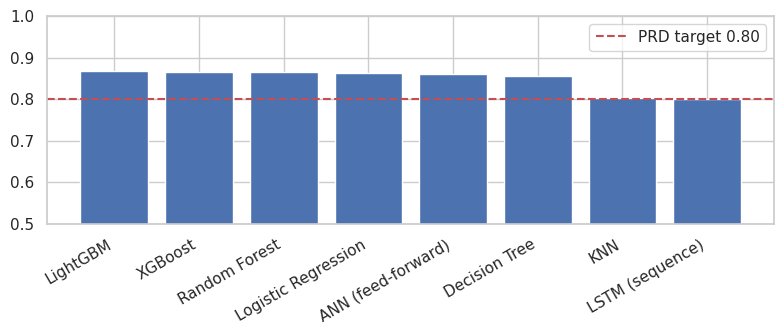

In [3]:
fig, ax = plt.subplots(figsize=(8,3.5)); ax.bar(cmp.model_name, cmp.roc_auc); ax.axhline(0.80, color='r', ls='--', label='PRD target 0.80'); ax.set_ylim(0.5, 1); plt.xticks(rotation=30, ha='right'); ax.legend(); plt.tight_layout(); plt.show()

## Class imbalance: class weights vs SMOTE (logistic regression, validation AUC / recall)
SMOTE is fitted inside each training fold only.

In [4]:
import joblib
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

from src.models.common import make_splits

ft = joblib.load(artifacts_path(cfg, 'transformer.joblib'))
f = pd.read_csv(path_of(cfg, 'features_train'))
X = ft.transform(f)[meta['model_features']]; y = f.churn.to_numpy(); sp = make_splits(y, cfg)
rows = []
for name, steps in {'class_weight': [('s', StandardScaler()), ('c', LogisticRegression(class_weight='balanced', max_iter=2000))],
                    'SMOTE': [('s', StandardScaler()), ('o', SMOTE(random_state=cfg['project']['seed'])), ('c', LogisticRegression(max_iter=2000))]}.items():
    m = Pipeline(steps).fit(X.iloc[sp['train']], y[sp['train']]); p = m.predict_proba(X.iloc[sp['val']])[:,1]
    rows.append((name, roc_auc_score(y[sp['val']], p), recall_score(y[sp['val']], p>0.5)))
pd.DataFrame(rows, columns=['method','val_auc','val_recall@0.5']).round(3)

,method,val_auc,val_recall@0.5
0,class_weight,0.859,0.755
1,SMOTE,0.859,0.755


## Convergence (training vs validation loss)

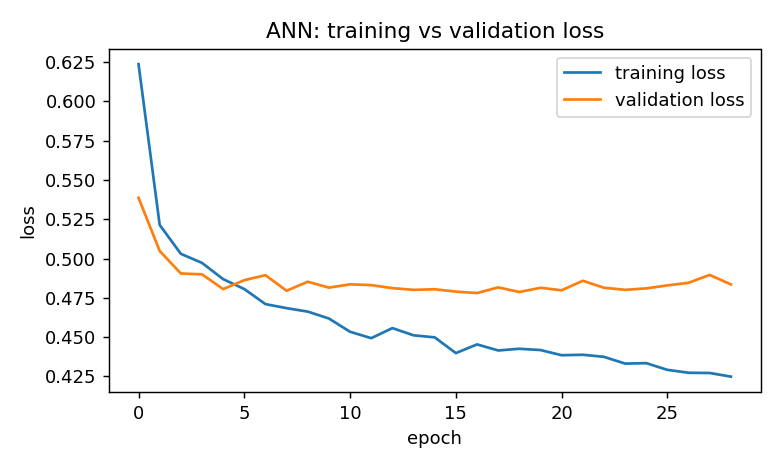

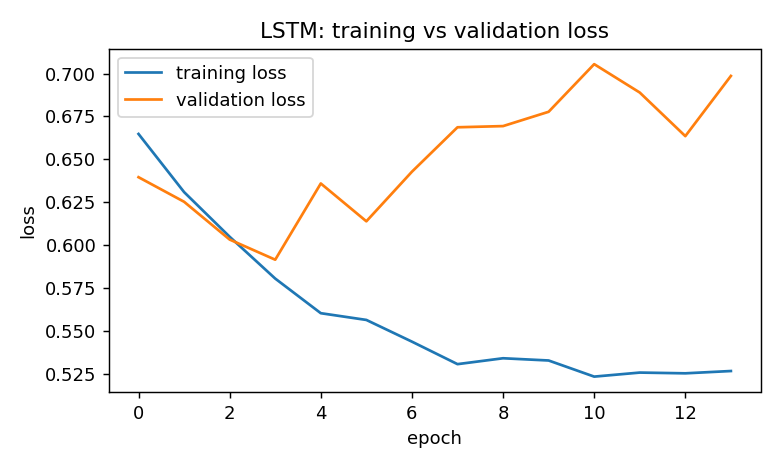

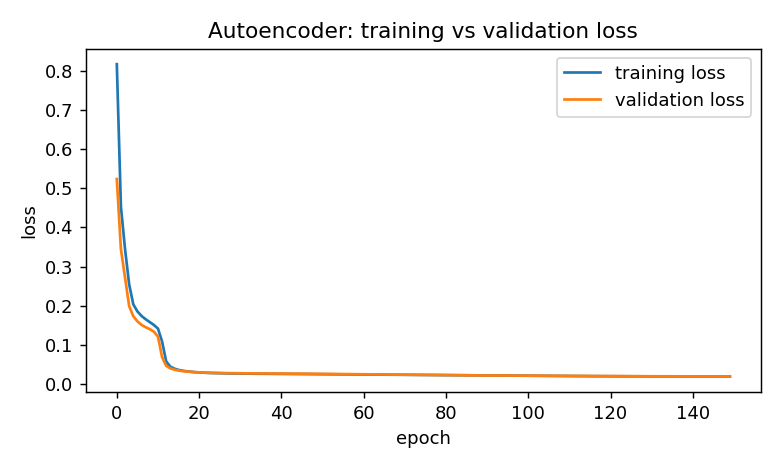

In [5]:
from IPython.display import Image, display

for n in ['loss_curve_ann.png','loss_curve_lstm.png','loss_curve_autoencoder.png']:
    display(Image(str(path_of(cfg, 'figures_dir') / n)))

## CLV, anomaly detection, segmentation

In [6]:
print(json.dumps(json.loads(artifacts_path(cfg,'metrics','clv_metrics.json').read_text()), indent=1)[:1500])
print(json.dumps(json.loads(artifacts_path(cfg,'metrics','anomaly_report.json').read_text()), indent=1))

{
 "ridge": {
  "val": {
   "mae": 347.35493801386866,
   "rmse": 737.4502355401384,
   "r2": 0.1610692317623661
  },
  "test": {
   "mae": 336.1648377763244,
   "rmse": 697.1176652975994,
   "r2": 0.11623825977237279
  },
  "params": {
   "alpha": 100.0
  },
  "cv_r2": 0.1746541997244646
 },
 "xgb_regressor": {
  "val": {
   "mae": 329.6156295632669,
   "rmse": 1092.8934017390743,
   "r2": -0.8425373204848055
  },
  "test": {
   "mae": 268.06028340060243,
   "rmse": 610.8639477883577,
   "r2": 0.3214028849006352
  },
  "params": {
   "n_estimators": 200,
   "max_depth": 3,
   "learning_rate": 0.03
  },
  "cv_r2": -0.04864985218047953
 },
 "selected": "ridge"
}
{
 "threshold": 7.591876029968262,
 "percentile": 99.0,
 "flag_rate_train": 0.010189228529839884,
 "flag_rate_val": 0.014705882352941176,
 "flag_rate_test": 0.014705882352941176,
 "n_flagged_test": 13,
 "spearman_vs_mahalanobis": 0.3240276383151269,
 "spearman_vs_isolation_forest": 0.20920369825274587,
 "flagged_in_isolation_for

In [7]:
pd.read_csv(artifacts_path(cfg,'metrics','segment_profiles.csv')).round(2)

,segment_id,segment_label,customers,share_pct,recency_days,frequency,total_spend,avg_spend,avg_basket_size,return_rate,seasonal_concentration,discount_sensitivity,engagement_score,mean_churn_probability,high_risk_pct
0,0,At-Risk / Lapsing (A),512,8.5,297.30,4.71,547.67,119.37,57.17,0.02,0.47,0.50,38.75,0.69,80.08
1,1,Loyal High-Value,456,7.6,192.22,11.21,7860.90,764.79,343.64,0.02,0.30,0.14,70.46,0.53,58.99
2,2,Steady Mid-Value (A),1638,27.3,39.57,20.22,2648.50,129.90,57.87,0.03,0.19,0.14,82.06,0.21,13.68
3,3,Steady Mid-Value,2211,36.8,270.86,6.20,828.91,144.02,63.51,0.02,0.33,0.10,47.70,0.70,84.44
4,4,Seasonal Gift Shopper,818,13.6,412.48,1.92,174.24,102.32,45.27,0.00,0.80,0.07,19.27,0.84,95.60
5,5,At-Risk / Lapsing,365,6.1,330.79,3.52,455.32,148.78,67.19,0.12,0.54,0.14,33.09,0.74,86.30


## Explainability

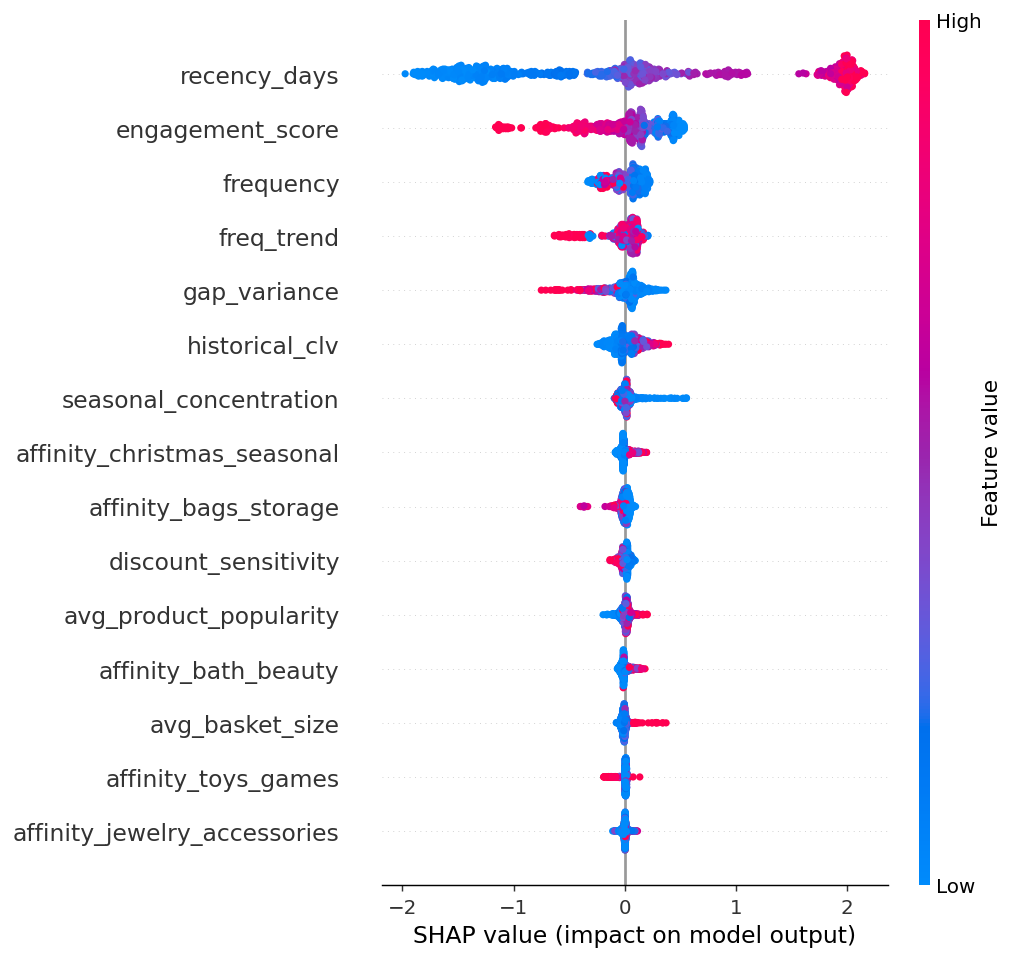

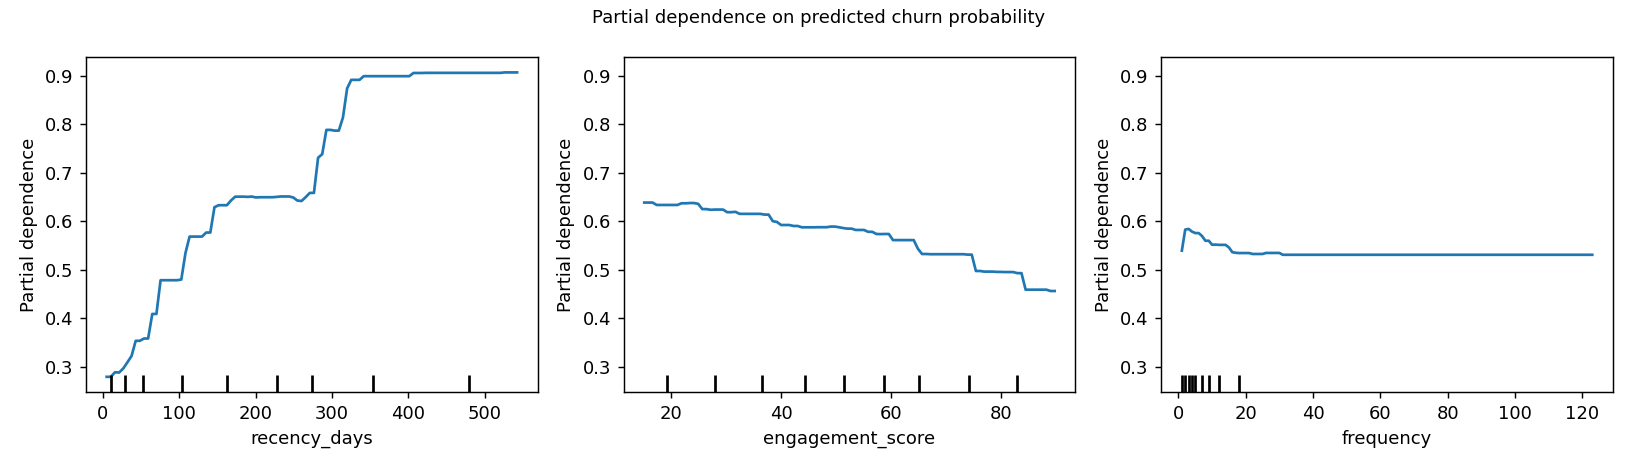

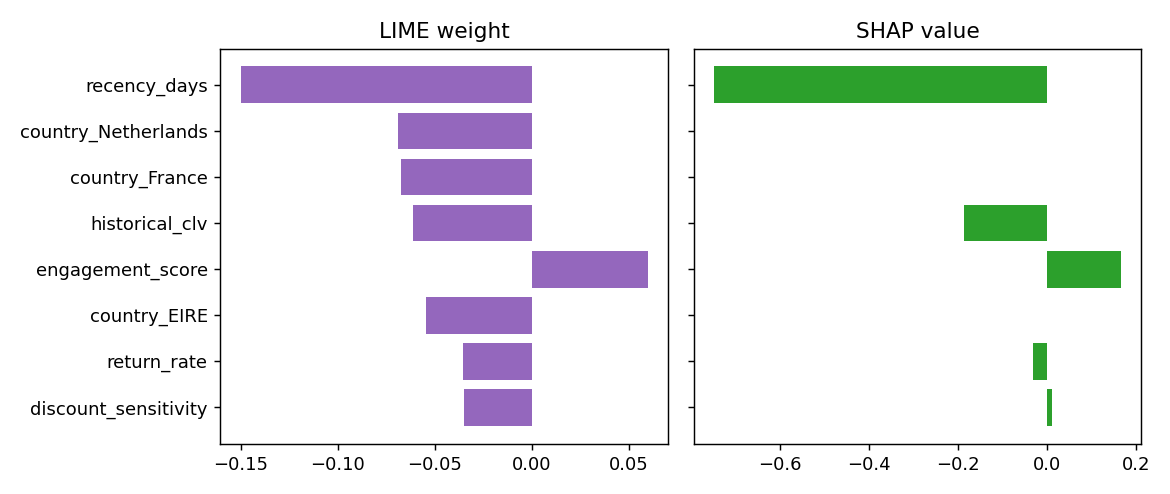

This customer is flagged as HIGH churn risk: predicted churn probability 32%, at or above the 32% operating threshold. Main drivers (relative to the average customer): days since last purchase = 71.00 (lower than typical) lowers the risk; number of orders = 1.00 (lower than typical) lowers the risk; net lifetime revenue = 101.84 (lower than typical) lowers the risk.


In [8]:
for n in ['shap_summary.png','pdp_top_features.png','lime_vs_shap.png']:
    display(Image(str(path_of(cfg, 'figures_dir') / n)))
print(json.loads(artifacts_path(cfg,'metrics','explain_report.json').read_text())['example_explanation'])